In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
MODEL_COLORS = {
    "Fixed": "#1f77b4",              # blue
    "Linear": "#ff7f0e",             # orange
    "Interference-Based": "#2ca02c", # green
    "Logarithmic": "#8B1E3F",        # burgundy
    "Threshold-Based": "#FF69B4",    # pink
}

MODEL_ORDER = [
    "Fixed",
    "Linear",
    "Interference-Based",
    "Logarithmic",
    "Threshold-Based"
]

In [ ]:
#Data for sequence length

data = [
    [7, "Fixed", 0.349, 0.866, 0.556, 0.399, 0.286, 0.161, 0.075, 0.102, None, None],
    [7, "Linear", 0.250, 0.748, 0.413, 0.277, 0.140, 0.091, 0.046, 0.037, None, None],
    [7, "Interference-Based", 0.258, 0.778, 0.439, 0.284, 0.162, 0.080, 0.027, 0.035, None, None],
    [7, "Logarithmic", 0.259, 0.768, 0.447, 0.303, 0.142, 0.076, 0.036, 0.043, None, None],
    [7, "Threshold-Based", 0.504, 0.915, 0.740, 0.597, 0.443, 0.332, 0.201, 0.297, None, None],

    [5, "Fixed", 0.611, 0.927, 0.731, 0.536, 0.361, 0.500, None, None, None, None],
    [5, "Linear", 0.521, 0.907, 0.658, 0.435, 0.239, 0.368, None, None, None, None],
    [5, "Interference-Based", 0.523, 0.909, 0.652, 0.450, 0.242, 0.364, None, None, None, None],
    [5, "Logarithmic", 0.519, 0.896, 0.651, 0.433, 0.233, 0.381, None, None, None, None],
    [5, "Threshold-Based", 0.739, 0.970, 0.851, 0.698, 0.538, 0.639, None, None, None, None],

    [6, "Fixed", 0.488, 0.905, 0.650, 0.478, 0.327, 0.218, 0.351, None, None, None],
    [6, "Linear", 0.359, 0.848, 0.522, 0.319, 0.162, 0.126, 0.178, None, None, None],
    [6, "Interference-Based", 0.375, 0.868, 0.525, 0.359, 0.204, 0.127, 0.167, None, None, None],
    [6, "Logarithmic", 0.375, 0.851, 0.513, 0.360, 0.194, 0.125, 0.208, None, None, None],
    [6, "Threshold-Based", 0.646, 0.947, 0.789, 0.665, 0.492, 0.421, 0.560, None, None, None],

    [8, "Fixed", 0.262, 0.775, 0.504, 0.387, 0.220, 0.132, 0.038, 0.007, 0.033, None],
    [8, "Linear", 0.179, 0.671, 0.329, 0.234, 0.108, 0.046, 0.013, 0.012, 0.018, None],
    [8, "Interference-Based", 0.180, 0.654, 0.333, 0.221, 0.125, 0.062, 0.017, 0.007, 0.018, None],
    [8, "Logarithmic", 0.188, 0.660, 0.342, 0.266, 0.129, 0.065, 0.019, 0.007, 0.014, None],
    [8, "Threshold-Based", 0.398, 0.897, 0.705, 0.578, 0.422, 0.296, 0.114, 0.038, 0.136, None],

    [9, "Fixed", 0.193, 0.711, 0.412, 0.301, 0.152, 0.098, 0.030, 0.006, 0.006, 0.021],
    [9, "Linear", 0.134, 0.604, 0.269, 0.195, 0.077, 0.033, 0.006, 0.004, 0.008, 0.010],
    [9, "Interference-Based", 0.134, 0.573, 0.262, 0.201, 0.094, 0.042, 0.018, 0.001, 0.003, 0.010],
    [9, "Logarithmic", 0.137, 0.598, 0.284, 0.192, 0.091, 0.043, 0.007, 0.006, 0.006, 0.007],
    [9, "Threshold-Based", 0.317, 0.835, 0.660, 0.546, 0.383, 0.236, 0.079, 0.023, 0.006, 0.083],
]

columns = [
    "Sequence Length", "Model", "Overall Accuracy",
    "Pos1", "Pos2", "Pos3", "Pos4", "Pos5", "Pos6", "Pos7", "Pos8", "Pos9"
]

df = pd.DataFrame(data, columns=columns)


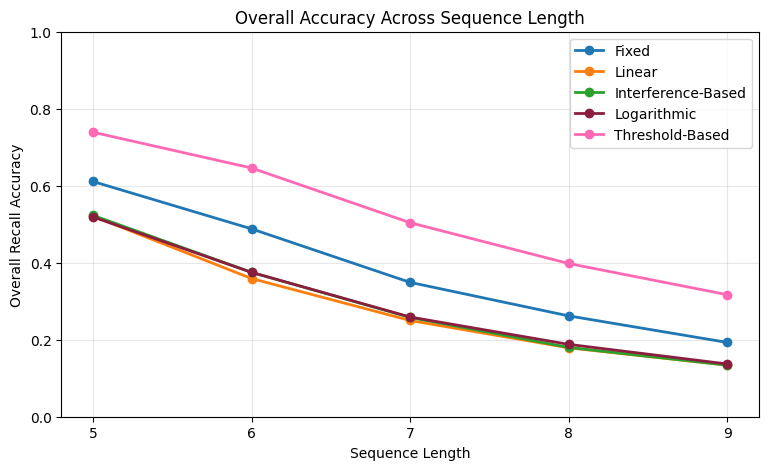

In [ ]:
#Overall Accuracy Across Sequence Length
plt.figure(figsize=(9, 5))

for model in MODEL_ORDER:
    model_df = df[df["Model"] == model].sort_values("Sequence Length")
    plt.plot(
        model_df["Sequence Length"],
        model_df["Overall Accuracy"],
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[model],
        label=model
    )

plt.title("Overall Accuracy Across Sequence Length")
plt.xlabel("Sequence Length")
plt.ylabel("Overall Recall Accuracy")
plt.xticks(sorted(df["Sequence Length"].unique()))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("fig_overall_accuracy_sequence_length.png", dpi=300, bbox_inches="tight")
plt.show()

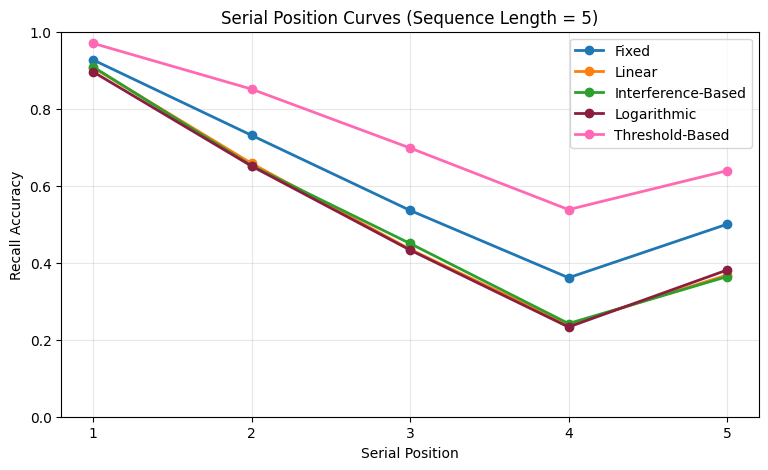

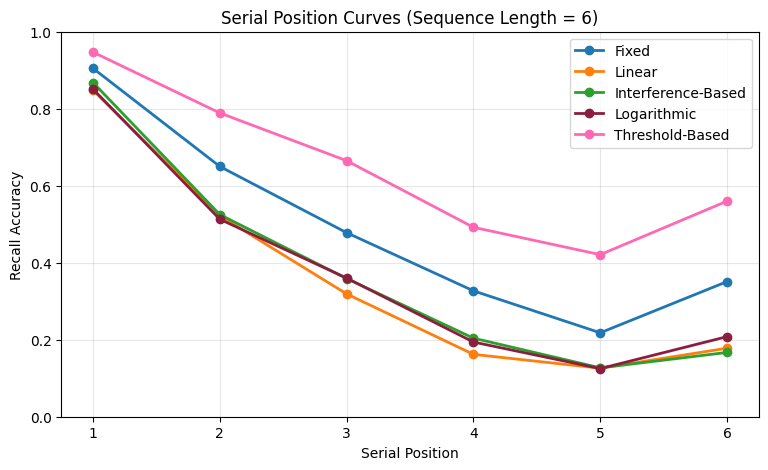

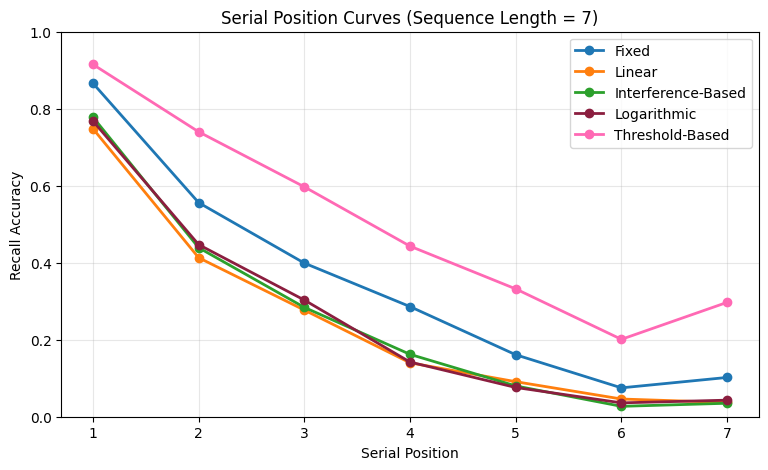

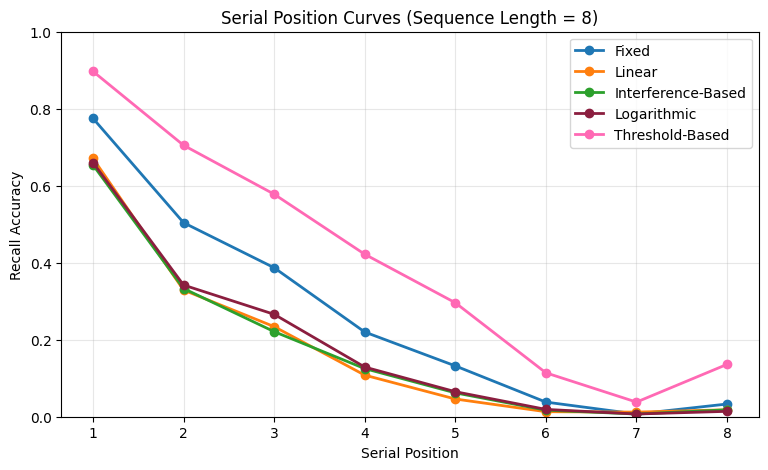

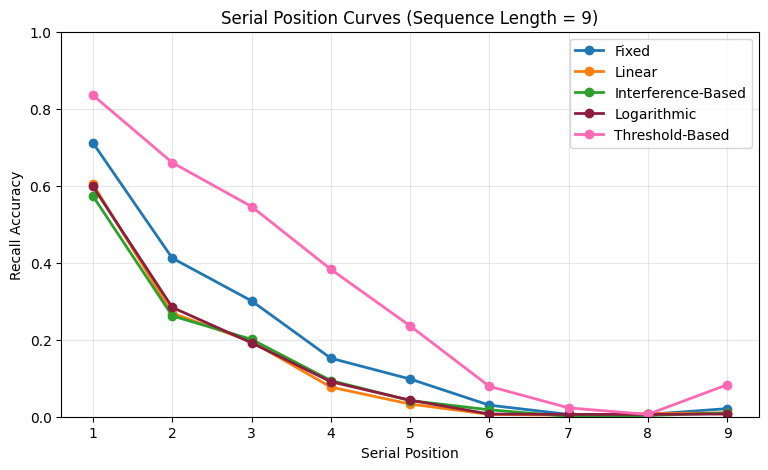

In [ ]:
#Serial Position Curves for Each Sequence Length

position_cols = ["Pos1", "Pos2", "Pos3", "Pos4", "Pos5", "Pos6", "Pos7", "Pos8", "Pos9"]

for seq_len in sorted(df["Sequence Length"].unique()):
    plt.figure(figsize=(9, 5))

    seq_df = df[df["Sequence Length"] == seq_len]

    for model in MODEL_ORDER:
        row = seq_df[seq_df["Model"] == model].iloc[0]

        positions = list(range(1, seq_len + 1))
        values = [row[f"Pos{i}"] for i in range(1, seq_len + 1)]

        plt.plot(
            positions,
            values,
            marker="o",
            linewidth=2,
            color=MODEL_COLORS[model],
            label=model
        )

    plt.title(f"Serial Position Curves (Sequence Length = {seq_len})")
    plt.xlabel("Serial Position")
    plt.ylabel("Recall Accuracy")
    plt.xticks(range(1, seq_len + 1))
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f"fig_serial_position_seq{seq_len}.png", dpi=300, bbox_inches="tight")
    plt.show()

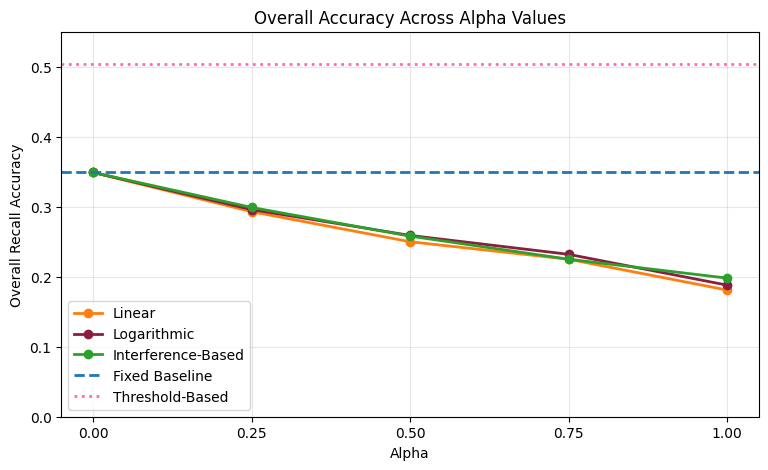

In [ ]:
##ALPHA SENSITIVITY TESTING

#Data for Alpha testing
alphas = [0, 0.25, 0.5, 0.75, 1.0]

overall_accuracy = {
    "Linear": [0.349, 0.293, 0.250, 0.225, 0.181],
    "Logarithmic": [0.349, 0.296, 0.259, 0.232, 0.188],
    "Interference-Based": [0.349, 0.299, 0.258, 0.225, 0.198],
}

#Reference lines
fixed_baseline = 0.349
threshold_baseline = 0.504


plt.figure(figsize=(9, 5))

for model, values in overall_accuracy.items():
    plt.plot(
        alphas,
        values,
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[model],
        label=model
    )


plt.axhline(
    y=fixed_baseline,
    linestyle="--",
    linewidth=2,
    color=MODEL_COLORS["Fixed"],
    label="Fixed Baseline"
)

plt.axhline(
    y=threshold_baseline,
    linestyle=":",
    linewidth=2,
    color=MODEL_COLORS["Threshold-Based"],
    label="Threshold-Based"
)

plt.title("Overall Accuracy Across Alpha Values")
plt.xlabel("Alpha")
plt.ylabel("Overall Recall Accuracy")
plt.xticks(alphas)
plt.ylim(0, 0.55)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("fig_alpha_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
##NBOP TESTING

NBOP_STYLES = {
    2: "-",
    4: "--",
    6: ":"
}

##NBOP Data
data = [
    [7, 2, "Fixed", 0.471, 0.910, 0.685, 0.511, 0.347, 0.273, 0.203, 0.367],
    [7, 2, "Linear", 0.334, 0.835, 0.533, 0.319, 0.223, 0.146, 0.092, 0.193],
    [7, 2, "Interference-Based", 0.349, 0.848, 0.532, 0.367, 0.245, 0.183, 0.086, 0.183],
    [7, 2, "Logarithmic", 0.355, 0.845, 0.531, 0.369, 0.247, 0.176, 0.099, 0.219],
    [7, 2, "Threshold-Based", 0.646, 0.967, 0.821, 0.699, 0.548, 0.495, 0.426, 0.564],

    [7, 4, "Fixed", 0.349, 0.866, 0.556, 0.399, 0.286, 0.161, 0.075, 0.102],
    [7, 4, "Linear", 0.250, 0.748, 0.413, 0.277, 0.140, 0.091, 0.046, 0.037],
    [7, 4, "Interference-Based", 0.258, 0.778, 0.439, 0.284, 0.162, 0.080, 0.027, 0.035],
    [7, 4, "Logarithmic", 0.259, 0.768, 0.447, 0.303, 0.142, 0.076, 0.036, 0.043],
    [7, 4, "Threshold-Based", 0.504, 0.915, 0.740, 0.597, 0.443, 0.332, 0.201, 0.297],

    [7, 6, "Fixed", 0.287, 0.805, 0.480, 0.351, 0.191, 0.111, 0.045, 0.028],
    [7, 6, "Linear", 0.208, 0.713, 0.346, 0.228, 0.095, 0.039, 0.018, 0.018],
    [7, 6, "Interference-Based", 0.210, 0.696, 0.345, 0.248, 0.112, 0.046, 0.019, 0.006],
    [7, 6, "Logarithmic", 0.214, 0.707, 0.357, 0.231, 0.102, 0.061, 0.024, 0.015],
    [7, 6, "Threshold-Based", 0.408, 0.857, 0.651, 0.552, 0.369, 0.228, 0.104, 0.094],
]

columns = [
    "Sequence Length", "nbop", "Model", "Overall Accuracy",
    "Pos1", "Pos2", "Pos3", "Pos4", "Pos5", "Pos6", "Pos7"
]

df = pd.DataFrame(data, columns=columns)

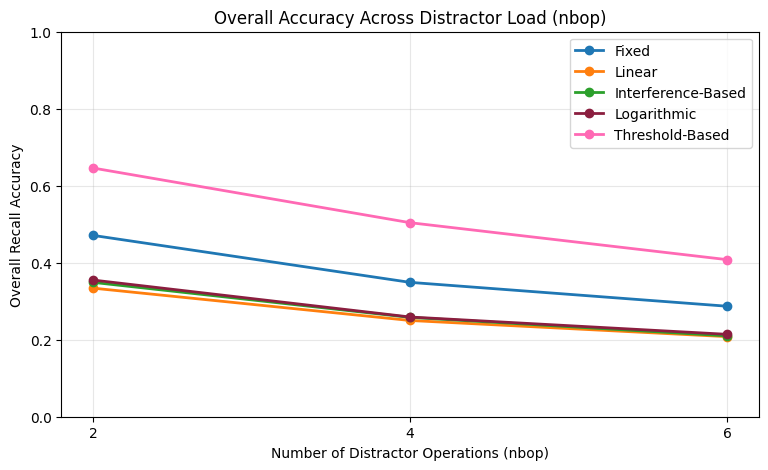

In [ ]:
# Overall Accuracy Across nbop
plt.figure(figsize=(9, 5))

for model in MODEL_ORDER:
    model_df = df[df["Model"] == model].sort_values("nbop")
    plt.plot(
        model_df["nbop"],
        model_df["Overall Accuracy"],
        marker="o",
        linewidth=2,
        color=MODEL_COLORS[model],
        label=model
    )

plt.title("Overall Accuracy Across Distractor Load (nbop)")
plt.xlabel("Number of Distractor Operations (nbop)")
plt.ylabel("Overall Recall Accuracy")
plt.xticks(sorted(df["nbop"].unique()))
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("fig_nbop_overall_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

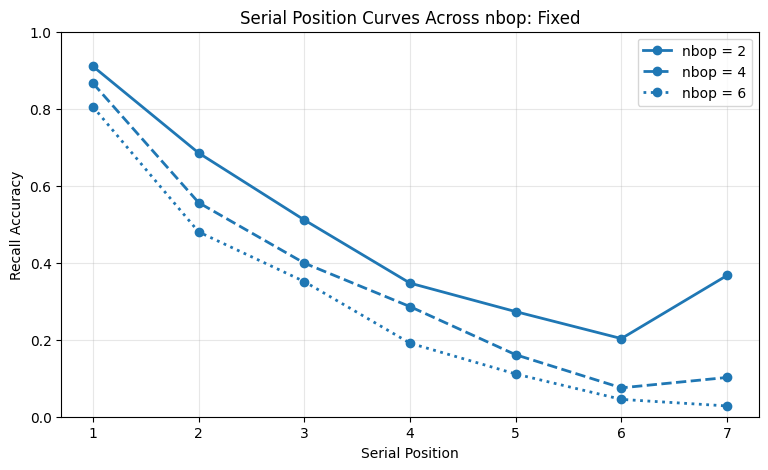

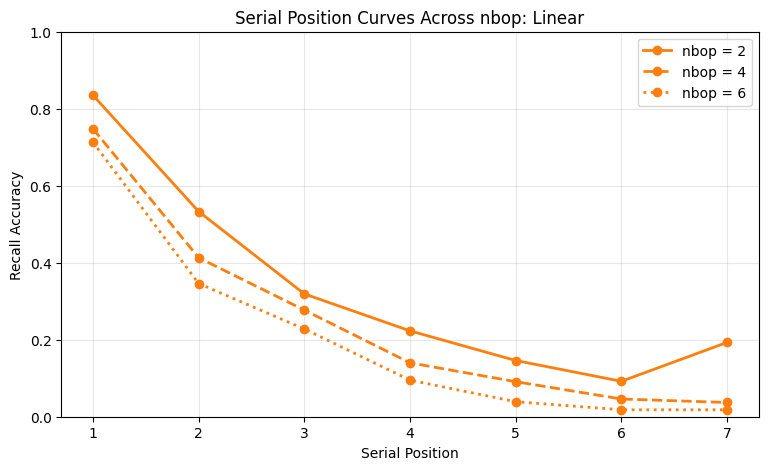

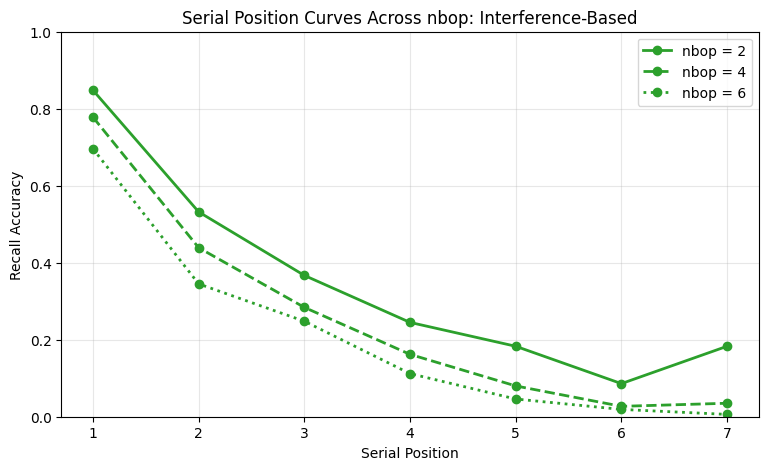

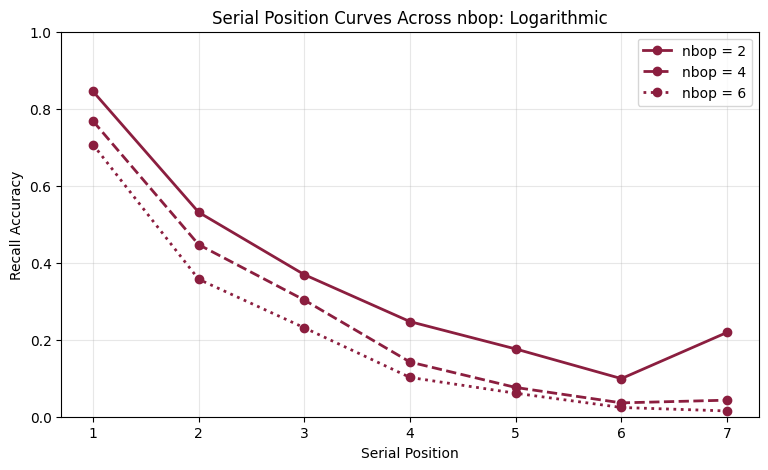

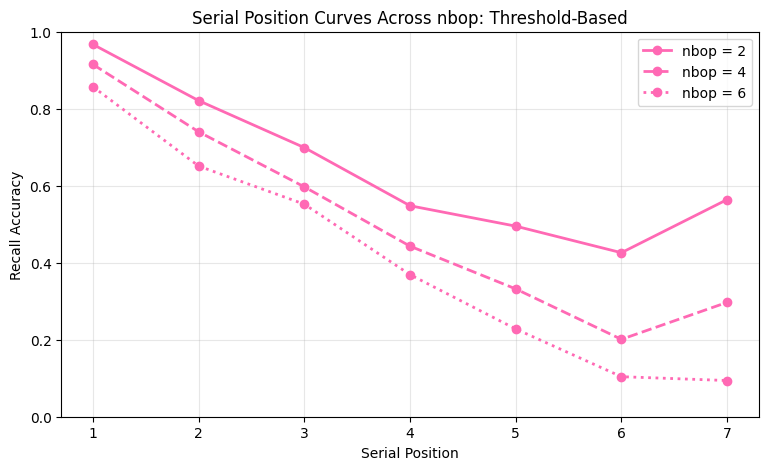

In [ ]:
# Accuracy per NBOP

for model in MODEL_ORDER:
    plt.figure(figsize=(9, 5))

    model_df = df[df["Model"] == model].sort_values("nbop")

    for _, row in model_df.iterrows():
        nbop = row["nbop"]
        positions = [1, 2, 3, 4, 5, 6, 7]
        values = [row["Pos1"], row["Pos2"], row["Pos3"], row["Pos4"], row["Pos5"], row["Pos6"], row["Pos7"]]

        plt.plot(
            positions,
            values,
            marker="o",
            linewidth=2,
            linestyle=NBOP_STYLES[nbop],
            color=MODEL_COLORS[model],
            label=f"nbop = {nbop}"
        )

    plt.title(f"Serial Position Curves Across nbop: {model}")
    plt.xlabel("Serial Position")
    plt.ylabel("Recall Accuracy")
    plt.xticks(positions)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()

    filename = "fig_nbop_serial_" + model.lower().replace("-based", "").replace("-", "_").replace(" ", "_") + ".png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

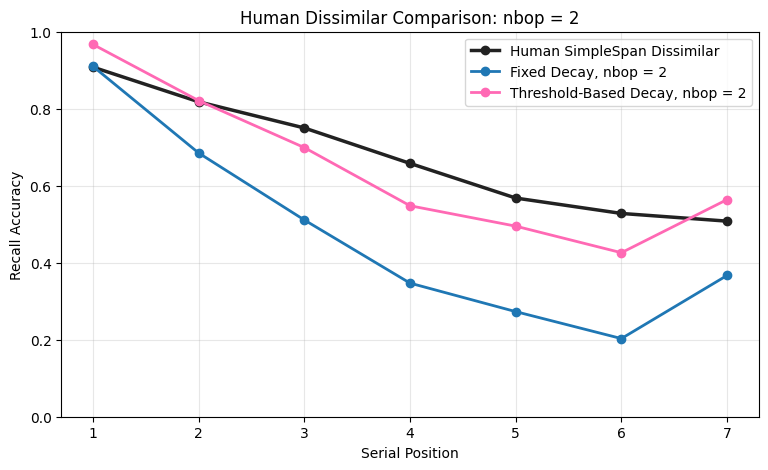

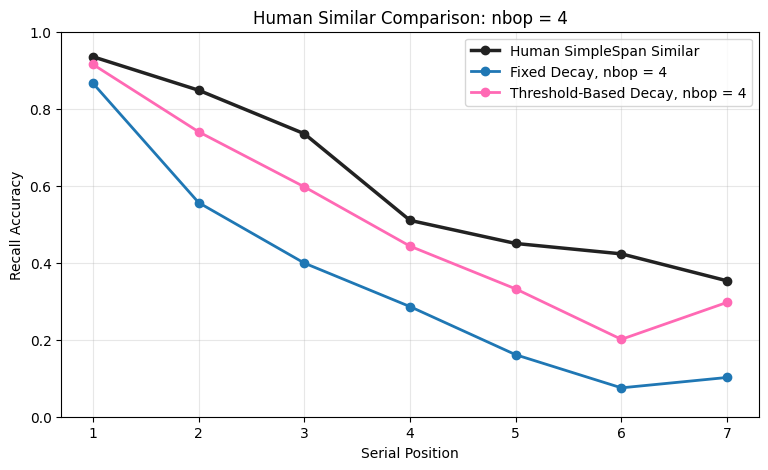

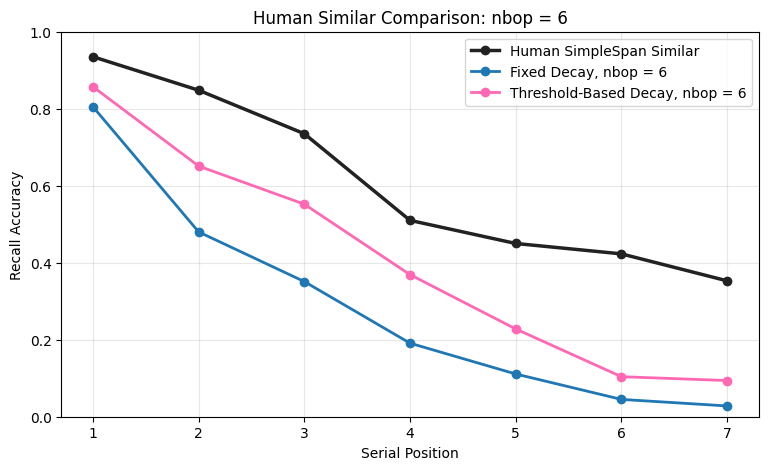

In [ ]:
#Comparison with Literature
PAPER_COLOR = "#222222"  # dark gray for human empirical data

positions = [1, 2, 3, 4, 5, 6, 7]

# Human SimpleSpan data from paper
paper_simple_similar = [0.935, 0.848, 0.735, 0.510, 0.450, 0.423, 0.353]
paper_simple_dissimilar = [0.908, 0.818, 0.750, 0.658, 0.568, 0.528, 0.508]

# Model data
fixed_nbop2 = [0.910, 0.685, 0.511, 0.347, 0.273, 0.203, 0.367]
threshold_nbop2 = [0.967, 0.821, 0.699, 0.548, 0.495, 0.426, 0.564]

fixed_nbop4 = [0.866, 0.556, 0.399, 0.286, 0.161, 0.075, 0.102]
threshold_nbop4 = [0.915, 0.740, 0.597, 0.443, 0.332, 0.201, 0.297]

fixed_nbop6 = [0.805, 0.480, 0.351, 0.191, 0.111, 0.045, 0.028]
threshold_nbop6 = [0.857, 0.651, 0.552, 0.369, 0.228, 0.104, 0.094]

def plot_human_comparison(
    human_values,
    human_label,
    fixed_values,
    threshold_values,
    nbop,
    title,
    filename
):
    plt.figure(figsize=(9, 5))

    plt.plot(
        positions,
        human_values,
        marker="o",
        linewidth=2.5,
        color=PAPER_COLOR,
        label=human_label
    )

    plt.plot(
        positions,
        fixed_values,
        marker="o",
        linewidth=2,
        color=MODEL_COLORS["Fixed"],
        label=f"Fixed Decay, nbop = {nbop}"
    )

    plt.plot(
        positions,
        threshold_values,
        marker="o",
        linewidth=2,
        color=MODEL_COLORS["Threshold-Based"],
        label=f"Threshold-Based Decay, nbop = {nbop}"
    )

    plt.title(title)
    plt.xlabel("Serial Position")
    plt.ylabel("Recall Accuracy")
    plt.xticks(positions)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

#Dissimilar human data vs nbop = 2
plot_human_comparison(
    human_values=paper_simple_dissimilar,
    human_label="Human SimpleSpan Dissimilar",
    fixed_values=fixed_nbop2,
    threshold_values=threshold_nbop2,
    nbop=2,
    title="Human Dissimilar Comparison: nbop = 2",
    filename="fig_human_comparison_dissimilar_nbop2.png"
)

# Graph 2: Similar human data vs nbop = 4
plot_human_comparison(
    human_values=paper_simple_similar,
    human_label="Human SimpleSpan Similar",
    fixed_values=fixed_nbop4,
    threshold_values=threshold_nbop4,
    nbop=4,
    title="Human Similar Comparison: nbop = 4",
    filename="fig_human_comparison_similar_nbop4.png"
)

# Graph 3: Similar human data vs nbop = 6
plot_human_comparison(
    human_values=paper_simple_similar,
    human_label="Human SimpleSpan Similar",
    fixed_values=fixed_nbop6,
    threshold_values=threshold_nbop6,
    nbop=6,
    title="Human Similar Comparison: nbop = 6",
    filename="fig_human_comparison_similar_nbop6.png"
)